Import packages

In [28]:
import os
import pandas as pd
import numpy as np
import skfuzzy as fuzz
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import pickle
import joblib
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import mean_absolute_error, classification_report, accuracy_score
from sklearn.ensemble import VotingClassifier
from sklearn.utils.multiclass import unique_labels
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [29]:
# Define the path to the CSV file
DATA_PATH = '../data/raw/Intuilize_MNSU_ACME_SalesData.csv'
OUTPUT_DIR = '../data/'
TIME_START = '2022-01-01'
TIME_END = '2023-12-31'
# Can be Weekly, BiWeekly, Monthly, Quarterly, Halfyear, & Yearly
TIME_SEPERATION = 'Quarterly'
# Must use Fuzzy C-Means Clustering
CLUSTER_NUMBER = 6
TESTING = True
EARLY_STOP_COUNT = 9


In [30]:
def save_feature_weights(feature_weights, output_file="feature_weights.csv", top_n=None, custom_features=None, normalize_subset=False):
    """
    Save feature weights to a CSV file.
    
    Parameters:
    - feature_weights (pd.DataFrame): DataFrame with feature weights (index: feature names, column: FinalWeight).
    - output_file (str): Name of the output CSV file.
    - top_n (int, optional): Number of top features to save (based on FinalWeight). If None, saves all.
    - custom_features (list, optional): List of specific feature names to save. Overrides top_n if provided.
    - normalize_subset (bool): If True, re-normalize the weights of the selected features to sum to 1.
    """
    # Select features to save
    if custom_features is not None:
        # Use custom feature list
        if not all(f in feature_weights.index for f in custom_features):
            raise ValueError("Some custom features not found in feature_weights index")
        df_to_save = feature_weights.loc[custom_features, ["FinalWeight"]]
    elif top_n is not None:
        # Use top N features
        df_to_save = feature_weights[["FinalWeight"]].nlargest(top_n, "FinalWeight")
    else:
        # Save all features
        df_to_save = feature_weights[["FinalWeight"]]
    
    # Re-normalize weights if requested
    if normalize_subset and not df_to_save.empty:
        df_to_save["FinalWeight"] = df_to_save["FinalWeight"] / df_to_save["FinalWeight"].sum()
    
    # Save to CSV
    df_to_save.to_csv(output_file, index=True, index_label="Feature")
    
    # Print confirmation
    print(f"Saved features and weights to '{output_file}'")
    print(f"Number of features saved: {len(df_to_save)}")
    print(f"Sum of weights: {df_to_save['FinalWeight'].sum():.6f}")


In [31]:
#cleanup directories data/processed/TIME_SEPERATION & data/segmented/TIME_SEPERATION
def cleanup_directories():
    # Remove the processed and segmented directories if they exist
    for dir_name in ['processed', 'segmented']:
        dir_path = os.path.join(OUTPUT_DIR, dir_name, TIME_SEPERATION)
        if os.path.exists(dir_path):
            for file in os.listdir(dir_path):
                file_path = os.path.join(dir_path, file)
                if os.path.isfile(file_path):
                    os.remove(file_path)
            os.rmdir(dir_path)  # Remove the directory after cleaning up files
    print(f"Cleaned up directories: {OUTPUT_DIR}processed/{TIME_SEPERATION} & {OUTPUT_DIR}segmented/{TIME_SEPERATION}")




In [32]:
def process_file(file_path, output_dir, global_customers, time_seperation):
    # Read the monthly CSV file into a DataFrame
    df = pd.read_csv(file_path)
    # Convert SalesDate to datetime
    df['SalesDate'] = pd.to_datetime(df['SalesDate'])
    
    # --------------------
    # Step 1: Product-Level Aggregations
    product_metrics = df.groupby('ProductID').agg(
        TotalSalesPrice=('ExtPrice', 'sum'),
        TotalCost=('ExtCost', 'sum'),
        TotalProfit=('Profit', 'sum'),
        AvgUnitPrice=('UnitPrice', 'mean'),
        AvgUnitCost=('UnitCost', 'mean'),
        TotalSalesQty=('SalesQty', 'sum'),
        TotalOrders=('OrderNumber', 'nunique'),
        UniqueCustomers=('CustomerName', 'nunique'),
        PriceVolatility=('UnitPrice', 'std')
    ).reset_index()
    
    # Step 2: Compute Additional Metrics at Product Level
    product_metrics['ProfitMargin'] = product_metrics['TotalProfit'] / product_metrics['TotalSalesPrice']
    product_metrics['AvgOrderSize'] = product_metrics['TotalSalesQty'] / product_metrics['TotalOrders']
    product_metrics['RepeatPurchaseRatio'] = product_metrics['TotalOrders'] / product_metrics['UniqueCustomers']
    
    # Step 3: Identify Customers Who Bought Each Product
    product_customers = df.groupby('ProductID')['CustomerName'].unique().reset_index()
    product_customers['CustomerCount'] = product_customers['CustomerName'].apply(len)
    
    # Merge product metrics with customer count
    product_metrics = product_metrics.merge(product_customers[['ProductID', 'CustomerCount']], on='ProductID', how='left')
    
    # --------------------
    # Step 4: Compute Customer Lifetime
    customer_lifetime = df.groupby("CustomerName").agg(
        FirstPurchase=("SalesDate", "min"),
        LastPurchase=("SalesDate", "max")
    ).reset_index()
    customer_lifetime["CustomerLifetimeDays"] = (customer_lifetime["LastPurchase"] - customer_lifetime["FirstPurchase"]).dt.days
    
    # --------------------
    # Step 5: Compute Customer-Level Aggregations
    customer_metrics = df.groupby("CustomerName").agg(
        TotalRevenue=("ExtPrice", "sum"),
        TotalProfit=("Profit", "sum"),
        TotalUnitPrice=("UnitPrice", "sum"),
        TotalSalesQty=("SalesQty", "sum"),
        OrderCount=("OrderNumber", "nunique"),
        NumDistinctProducts=("ProductID", "nunique"),
        NumDistinctProductGroups=("ProductGroupID", "nunique"),
        BranchCount=("BranchName", "nunique"),
        TopProductID=("ProductID", lambda x: x.value_counts().idxmax()),
        TopProductGroupID=("ProductGroupID", lambda x: x.value_counts().idxmax()),
        ProductDiversityIndex=("ProductID", lambda x: len(x.unique()) / x.count()),
        ProductConcentrationIndex=("ExtPrice", lambda x: x.max() / x.sum()),
        TopProductRevenueShare=("ExtPrice", lambda x: x.groupby(df["ProductID"]).sum().max() / x.sum()),
        TopProductGroupRevenueShare=("ExtPrice", lambda x: x.groupby(df["ProductGroupID"]).sum().max() / x.sum())
    ).reset_index()
    
    # Merge customer lifetime data
    customer_metrics = customer_metrics.merge(customer_lifetime[["CustomerName", "CustomerLifetimeDays"]], on="CustomerName", how="left")
    
    # --------------------
    # Step 6: Compute Additional Customer Features
    customer_metrics['AvgOrderValue'] = customer_metrics['TotalRevenue'] / customer_metrics['OrderCount']
    customer_metrics['RepeatPurchaseRatio'] = customer_metrics['OrderCount'] / customer_metrics['NumDistinctProducts']
    
    # --------------------
    # Step 7: Merge Product-Level Profitability Metrics into Transactions DataFrame
    product_profit = product_metrics[['ProductID', 'TotalProfit']]
    df = df.merge(product_profit, on='ProductID', how='left')
    
    # --------------------
    # Step 8: Identify High-Profit and Popular Products
    high_profit_threshold = product_metrics['TotalProfit'].quantile(0.75)  # Top 25% profitable
    popular_product_threshold = product_metrics['TotalSalesQty'].quantile(0.75)  # Top 25% sold
    
    df['HighProfitProduct'] = df['Profit'] >= high_profit_threshold
    df['PopularProduct'] = df['SalesQty'] >= popular_product_threshold
    
    # --------------------
    # Step 9: Compute Customer Engagement with High-Profit & Popular Products
    customer_product_engagement = df.groupby('CustomerName').agg(
        HighProfitProductShare=('HighProfitProduct', 'mean'),
        PopularProductShare=('PopularProduct', 'mean'),
        HighProfitOrderRatio=('HighProfitProduct', 'sum'),
        PopularOrderRatio=('PopularProduct', 'sum')
    ).reset_index()
    
    # Final merge: Combine customer metrics with engagement features
    customer_metrics = customer_metrics.merge(customer_product_engagement, on='CustomerName', how='left')
    
    # --------------------
    # New Step: Ensure Every Customer Appears
    # Merge with global_customers (master list for 2022/2023) so every customer is included.
    # Assume global_customers has at least the column "CustomerName".
    global_names = global_customers["CustomerName"].unique()

    # Reindex the monthly customer_metrics to include all global_names
    customer_metrics = customer_metrics.set_index("CustomerName").reindex(global_names).reset_index()

    # Fill missing numeric values with 0 for customers who had no purchases that month
    numeric_cols = customer_metrics.select_dtypes(include=[np.number]).columns
    customer_metrics[numeric_cols] = customer_metrics[numeric_cols].fillna(0)
    
    # Alphabetize the customer metrics by CustomerName (a-z)
    customer_metrics = customer_metrics.sort_values("CustomerName")

    #Remove Customers if they have over 3000000 in profit in global customers
    low_profit_customers = global_customers.loc[global_customers["TotalProfit"] < 3000000, "CustomerName"].unique()
    customer_metrics = customer_metrics[customer_metrics["CustomerName"].isin(low_profit_customers)]

    # --------------------
    # Export the customer metrics file
    input_filename = os.path.basename(file_path)
    output_filename = f"customer_metrics_{input_filename}"
    # Create the output directory if it doesn't exist
    output_dir = os.path.join(output_dir, "processed")
    if (time_seperation != "All"):
        output_dir = os.path.join(output_dir, time_seperation)
    os.makedirs(output_dir, exist_ok=True)
    output_path = os.path.join(output_dir, output_filename)
    customer_metrics.to_csv(output_path, index=False)
    print(f"Processed {file_path} -> {output_path}")
    return output_path

In [33]:
def segment_data(data, time_start, time_end, time_seperation,output_dir):
    # Starting from the last data point, work backwards creating
    # yearly data files until we hit our starting threshold.
    timeframe = pd.Timedelta(days=30)  # Default to monthly if no match found
    if time_seperation == 'Weekly':
        timeframe = pd.Timedelta(weeks=1)
    elif time_seperation == 'BiWeekly':
        timeframe = pd.Timedelta(weeks=2)
    elif time_seperation == 'Monthly':
        timeframe = pd.Timedelta(days=30)  # Approximate monthly offset
    elif time_seperation == 'Quarterly':
        timeframe = pd.Timedelta(days=90)  # Approximate quarterly offset
    elif time_seperation == 'Halfyear':
        timeframe = pd.Timedelta(days=180)  # Approximate half-year offset
    elif time_seperation == 'Yearly':
        timeframe = pd.Timedelta(days=365)  # Approximate yearly offset

    time_store = pd.to_datetime(time_end) - timeframe  # Start from the end of the data
    time_start = pd.to_datetime(time_start)
    
    segmentList = []

    while time_store >= time_start:
        # Create a new DataFrame for the current segment
        data_segment = data[(data['SalesDate'] >= time_store) & (data['SalesDate'] <= time_store + timeframe)]
        #print the size of the data_segment
        print(f"Segment from {time_store} to {time_store + timeframe}: {data_segment.shape[0]} rows")
        segmentList.append(data_segment)
        # Move to the next iteration
        time_store -= timeframe
        
    segmentList.reverse()

    # Create the output directory if it doesn't exist
    output_dir = os.path.join(OUTPUT_DIR, "segmented", time_seperation)
    os.makedirs(output_dir, exist_ok=True)

    for i in range(1, segmentList.__len__()+1):
        data_segment = segmentList[i-1]
        # Generate the output filename
        # add zeros to the front of the number to make it 5 digits long
        index = str(i).zfill(5)
        output_filename = f"segmented_{time_seperation}_{index}.csv"
        output_path = os.path.join(output_dir, output_filename)
        
        # Save the yearly data to a CSV file
        data_segment.to_csv(output_path, index=False)

    return output_dir

In [34]:
data = pd.read_csv(DATA_PATH)
data['SalesDate'] = pd.to_datetime(data['SalesDate'])
data["Month"] = data["SalesDate"].dt.month
data["Year"] = data["SalesDate"].dt.year

# Calculate profit
data["Profit"] = data["ExtPrice"] - data["ExtCost"]

#Drop data outside of the time range
data = data[(data["SalesDate"] >= TIME_START) & (data["SalesDate"] <= TIME_END)]

segments_filepath = segment_data(data, TIME_START, TIME_END, TIME_SEPERATION, OUTPUT_DIR)
processed_filepath = os.path.join(OUTPUT_DIR, "processed", TIME_SEPERATION)

unique_customers = data['CustomerName'].unique()
name_to_alias = {name: f"Customer {i+1}" for i, name in enumerate(unique_customers)}
data['customer_alias'] = data['CustomerName'].map(name_to_alias)

customer_metrics = data.groupby(["CustomerID", "CustomerName"]).agg(
    TotalRevenue=("ExtPrice", "sum"),
    TotalProfit=("Profit", "sum"),
    PurchaseFrequency=("OrderNumber", "nunique"),
).reset_index()

all_data_filepath = os.path.join(OUTPUT_DIR, "all_data.csv")
data.to_csv(all_data_filepath, index=False)
all_data_processed_filepath = process_file(all_data_filepath, OUTPUT_DIR, customer_metrics, "All")

for file in os.listdir(segments_filepath):
    if file.endswith(".csv"):
        file_path = os.path.join(segments_filepath, file)
        process_file(file_path, OUTPUT_DIR, customer_metrics, TIME_SEPERATION)

Segment from 2023-10-02 00:00:00 to 2023-12-31 00:00:00: 92835 rows
Segment from 2023-07-04 00:00:00 to 2023-10-02 00:00:00: 98298 rows
Segment from 2023-04-05 00:00:00 to 2023-07-04 00:00:00: 97231 rows
Segment from 2023-01-05 00:00:00 to 2023-04-05 00:00:00: 106811 rows
Segment from 2022-10-07 00:00:00 to 2023-01-05 00:00:00: 98660 rows
Segment from 2022-07-09 00:00:00 to 2022-10-07 00:00:00: 114897 rows
Segment from 2022-04-10 00:00:00 to 2022-07-09 00:00:00: 119171 rows
Segment from 2022-01-10 00:00:00 to 2022-04-10 00:00:00: 120771 rows
Processed ../data/all_data.csv -> ../data/processed\customer_metrics_all_data.csv
Processed ../data/segmented\Quarterly\segmented_Quarterly_00001.csv -> ../data/processed\Quarterly\customer_metrics_segmented_Quarterly_00001.csv
Processed ../data/segmented\Quarterly\segmented_Quarterly_00002.csv -> ../data/processed\Quarterly\customer_metrics_segmented_Quarterly_00002.csv
Processed ../data/segmented\Quarterly\segmented_Quarterly_00003.csv -> ../data

Testing and selecting features

In [35]:
# Only run this cell if you have not already run the previous cell.
# This is used to save the features that can be used by the segmentation and prediction models

# Load dataset
input_file_path = DATA_PATH
data = pd.read_csv(input_file_path)
data["Profit"] = data["ExtPrice"] - data["ExtCost"]
data['SalesDate'] = pd.to_datetime(data['SalesDate'])

# Select number of features.
number_of_features_required = 8


# Product specific metric for Product Mix Analysis
product_metrics = data.groupby('ProductID').agg(
    TotalSalesPrice=('ExtPrice', 'sum'),
    TotalCost=('ExtCost', 'sum'),
    TotalProfit=('Profit', 'sum'),
    AvgUnitPrice=('UnitPrice', 'mean'),
    AvgUnitCost=('UnitCost', 'mean'),
    TotalSalesQty=('SalesQty', 'sum'),
    TotalOrders=('OrderNumber', 'nunique'),
    UniqueCustomers=('CustomerName', 'nunique'),
    PriceVolatility=('UnitPrice', 'std')
).reset_index()

# Compute Additional Metrics
product_metrics['ProfitMargin'] = product_metrics['TotalProfit'] / product_metrics['TotalSalesPrice']
product_metrics['AvgOrderSize'] = product_metrics['TotalSalesQty'] / product_metrics['TotalOrders']
product_metrics['RepeatPurchaseRatio'] = product_metrics['TotalOrders'] / product_metrics['UniqueCustomers']
# Identify and Group customers based on product information
product_customers = data.groupby('ProductID')['CustomerName'].unique().reset_index()
product_customers['CustomerCount'] = product_customers['CustomerName'].apply(len)
# Merge Customer Data
product_metrics = product_metrics.merge(product_customers[['ProductID', 'CustomerCount']], on='ProductID', how='left')

# Calculate customer lifetime (duration between first and last purchase)
customer_lifetime = data.groupby("CustomerName").agg(
    FirstPurchase=("SalesDate", "min"),
    LastPurchase=("SalesDate", "max")
).reset_index()

# Compute lifetime in days
customer_lifetime["CustomerLifetimeDays"] = (customer_lifetime["LastPurchase"] - customer_lifetime["FirstPurchase"]).dt.days

# Merge with customer_metrics
customer_metrics = data.groupby("CustomerName").agg(
    TotalRevenue=("ExtPrice", "sum"), # total revenue generated by the customer
    TotalProfit=("Profit", "sum"), # total profit generated by the customer
    TotalUnitPrice=("UnitPrice", "sum"), # total individual unit price for all purchases by the customer
    TotalSalesQty=("SalesQty", "sum"), # total quantity sold to the customer
    OrderCount=("OrderNumber", "nunique"), # total number of orders placed by the customer
    NumDistinctProducts=("ProductID", "nunique"), # number of distinct products purchased by the customer
    NumDistinctProductGroups=("ProductGroupID", "nunique"), # number of distinct product groups purchased by the customer
    BranchCount=("BranchName", "nunique"), # number of branches visited by the customer
    TopProductID=("ProductID", lambda x: x.value_counts().idxmax()), # most popular product purchased by the customer
    TopProductGroupID=("ProductGroupID", lambda x: x.value_counts().idxmax()), # most popular product group purchased by the customer
    ProductDiversityIndex=("ProductID", lambda x: len(x.unique()) / x.count()), # number of distinct products divided by the total sales quantity
    ProductConcentrationIndex=("ExtPrice", lambda x: x.max() / x.sum()), # revenue of the most expensive product divided by the total revenue
    TopProductRevenueShare=("ExtPrice", lambda x: x.groupby(data["ProductID"]).sum().max() / x.sum()), # revenue share of the most expensive product
    TopProductGroupRevenueShare=("ExtPrice", lambda x: x.groupby(data["ProductGroupID"]).sum().max() / x.sum()) # revenue share of the most expensive product group
).reset_index()

customer_metrics = customer_metrics.merge(customer_lifetime[["CustomerName", "CustomerLifetimeDays"]], on="CustomerName", how="left")

# Compute additional features
customer_metrics['AvgOrderValue'] = customer_metrics['TotalRevenue'] / customer_metrics['OrderCount'] # average order value
customer_metrics['RepeatPurchaseRatio'] = customer_metrics['OrderCount'] / customer_metrics['NumDistinctProducts'] # raio of number of orders and number of distinct products bought

# Merge with Product-Level Profitability Metrics
product_profit = product_metrics[['ProductID', 'TotalProfit']]
data = data.merge(product_profit, on='ProductID', how='left')

# Identify High-Profit and Popular Products
high_profit_threshold = product_metrics['TotalProfit'].quantile(0.75)  # Top 25% most profitable
popular_product_threshold = product_metrics['TotalSalesQty'].quantile(0.75)  # Top 25% most sold

data['HighProfitProduct'] = data['Profit'] >= high_profit_threshold # Top 25% most profitable
data['PopularProduct'] = data['SalesQty'] >= popular_product_threshold # Top 25% most sold

# Compute Customer Engagement with High-Profit & Popular Products
customer_product_engagement = data.groupby('CustomerName').agg(
    HighProfitProductShare=('HighProfitProduct', 'mean'), # percentage of orders with high-profit products
    PopularProductShare=('PopularProduct', 'mean'), # percentage of orders with popular products
    HighProfitOrderRatio=('HighProfitProduct', 'sum'), # number of orders with high-profit products
    PopularOrderRatio=('PopularProduct', 'sum') # number of orders with popular products
).reset_index()

# Merge into customer dataset
customer_metrics = customer_metrics.merge(customer_product_engagement, on='CustomerName', how='left')
goal = 'TotalRevenue' 

# Select numeric features only
numeric_features = customer_metrics.select_dtypes(include=[np.number]).columns.tolist()

# # Remove the target if included
# if goal in numeric_features:
#     numeric_features.remove(goal)

# Scale only the feature columns
scaler = StandardScaler()
customer_metrics[numeric_features] = scaler.fit_transform(customer_metrics[numeric_features])

# Train/test split
x = customer_metrics[numeric_features]
y = customer_metrics[goal]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42) 

# Feature analysis
correlation = x.corrwith(y) # Pandas correalation
feature_correlation = pd.DataFrame(correlation, columns=["Correlation"]).sort_values('Correlation', ascending=False)
rf = RandomForestRegressor(n_estimators=100, random_state=42) # Train the Random Forest model
rf.fit(x_train, y_train)
accuracy = rf.score(x_test, y_test) # Accuracy of the Random Forest model before feature selection
feature_importance = pd.DataFrame(rf.feature_importances_, index=x_train.columns, columns=['importance']).sort_values('importance', ascending=False) # Feature importance


# Calculate final weights
feature_correlation["Correlation"] = np.abs(feature_correlation["Correlation"])
feature_correlation["Correlation"] /= feature_correlation["Correlation"].sum()
feature_importance["importance"] /= feature_importance["importance"].sum() # Normalize feature importance (ensure it sums to 1)
feature_weights = feature_importance.merge(feature_correlation, left_index=True, right_index=True) # Merge Importance and Correlation into a single DataFrame
alpha = 0.6  # Adjustable weight factor
feature_weights["FinalWeight"] = (alpha * feature_weights["importance"]) + ((1 - alpha) * feature_weights["Correlation"])
feature_weights["FinalWeight"] /= feature_weights["FinalWeight"].sum() # Normalize Final Weights
# print("\nFeature Weights Based on Importance and Correlation:")
# print(feature_weights.sort_values("FinalWeight", ascending=False))
top_features = feature_weights.head(number_of_features_required).index.tolist()
print(f"Top {number_of_features_required} features based on Final Weights: {top_features}")
features_path = os.path.join(OUTPUT_DIR, 'features.csv')
# Save features and weights
save_feature_weights(feature_weights, output_file=features_path, top_n=8, normalize_subset=True)


Top 8 features based on Final Weights: ['TotalRevenue', 'TotalProfit', 'TotalSalesQty', 'OrderCount', 'TotalUnitPrice', 'ProductDiversityIndex', 'NumDistinctProductGroups', 'RepeatPurchaseRatio']
Saved features and weights to '../data/features.csv'
Number of features saved: 8
Sum of weights: 1.000000


In [36]:
features_path = os.path.join(OUTPUT_DIR, 'features.csv')
features_df = pd.read_csv(features_path)
features_columns = features_df['Feature'].to_list()
weights = features_df['FinalWeight'].to_list()

In [37]:
# run fuzzy c-means clustering against the full metrics
standardScaler = StandardScaler()
normalizedFeatures = standardScaler.fit_transform(pd.read_csv(all_data_processed_filepath)[features_columns])
weightedFeatures = normalizedFeatures * weights
fuzziness_parameter = 2
center, u, u0, distance, cost, partition_coeff, fuzz_partition_coeff = fuzz.cluster.cmeans(
            weightedFeatures.T, CLUSTER_NUMBER, fuzziness_parameter, error=.005, maxiter=1000
        )
cluster_names = {0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5}
hard_labels = np.argmax(u, axis=0)
# Compute weighted average revenue for ordering (assumes column 0 is revenue)
avg_revenue = []
for i in range(CLUSTER_NUMBER):
    # Select the revenue values from customer_metrics_scaled (column 0)
    revenue = normalizedFeatures[hard_labels == i, 0]
    # Compute the average revenue for cluster i
    if len(revenue) > 0:
        cluster_avg = np.mean(revenue)
    else:
        cluster_avg = 0
    avg_revenue.append(cluster_avg)
avg_revenue = np.array(avg_revenue)

# Create a mapping so that the lowest revenue cluster gets label 0 and the highest gets (CLUSTER_NUMBER-1)
order = np.argsort(avg_revenue)
mapping = np.empty_like(order)
mapping[order] = np.arange(CLUSTER_NUMBER)

# Save the model components
model_data = {
    'centers': center,
    'mapping': mapping,
    'cluster_names': cluster_names,
    'fuzziness_parameter': fuzziness_parameter,
    'num_clusters': CLUSTER_NUMBER
}
model_save_path = os.path.join(OUTPUT_DIR, 'saved_models', f'fuzzy_cmeans_model_{TIME_SEPERATION}.pkl')
# Create the directory if it doesn't exist
os.makedirs(os.path.dirname(model_save_path), exist_ok=True)
# Save to a file
with open(model_save_path, 'wb') as f:
    pickle.dump(model_data, f)


Prediction approach: predict the next cluster use the trend of how the customer has moved in the past.

In [38]:
cluster_reverse_mapping =joblib.load(model_save_path)['cluster_names']
cluster_mapping = {v: k for k, v in cluster_reverse_mapping.items()}

In [ ]:
# predicts the cluster for a dataframe
def predict_clusters(df_all_features,features_path = features_path, model_file=model_save_path):
    features_df = pd.read_csv(features_path)
    feature_columns = features_df['Feature'].to_list()
    weights = features_df['FinalWeight'].to_list()
    # scale features for prediction model
    df = df_all_features[feature_columns]
    standardScaler = StandardScaler()
    normalizedFeatures = standardScaler.fit_transform(df)
    #weights = [1,0.57821138, 0.10583493, 0.07332408, 0.07208094, 0.04819159,
    #0.01809966, 0.04088511, 0.03574647, 0.01459683, 0.01302901] # values from testing
    weightedFeatures = normalizedFeatures * weights

    # Load the saved model
    fuzzy_cmeans_model = joblib.load(model_file)
    centers = fuzzy_cmeans_model['centers']
    mapping = fuzzy_cmeans_model['mapping']
    cluster_names = fuzzy_cmeans_model['cluster_names']
    u_pred, _, _, _, _, _ = fuzz.cluster.cmeans_predict(
            weightedFeatures.T, centers, fuzzy_cmeans_model['fuzziness_parameter'], 
            error=0.005, maxiter=1000
        )
    # Get hard cluster assignments
    hard_labels_pred = np.argmax(u_pred, axis=0)

    # Apply the saved mapping
    renumbered_labels_pred = mapping[hard_labels_pred]

    # Convert to cluster names
    named_labels_pred = np.vectorize(cluster_names.get)(renumbered_labels_pred)
    # memebership_degree = u_pred
    return pd.Series(named_labels_pred)
    


In [40]:
def add_cluster_prediction(df_all_features,features_path = features_path, model_file=model_save_path):
    cluster_predictions = predict_clusters(df_all_features,features_path, model_file)
    df_all_features['cluster_prediction'] = cluster_predictions
    return df_all_features

In [41]:
unique_customers = pd.read_csv(DATA_PATH)["CustomerName"].unique()

# Creating customer specific time series

In [42]:
def get_customer_data_as_time_series(customer_name, input_dir = processed_filepath):
    df_for_customer = pd.DataFrame(columns=['CustomerName', 'TotalRevenue', 'TotalProfit', 'TotalUnitPrice',
       'TotalSalesQty', 'OrderCount', 'NumDistinctProducts',
       'NumDistinctProductGroups', 'BranchCount', 'TopProductID',
       'TopProductGroupID', 'ProductDiversityIndex',
       'ProductConcentrationIndex', 'TopProductRevenueShare',
       'TopProductGroupRevenueShare', 'CustomerLifetimeDays', 'AvgOrderValue',
       'RepeatPurchaseRatio', 'HighProfitProductShare', 'PopularProductShare',
       'HighProfitOrderRatio', 'PopularOrderRatio'])

    for file in os.listdir(input_dir):  # Sort files to ensure order
        if file.endswith(".csv"):
            file_path = os.path.join(input_dir, file)
            data = pd.read_csv(file_path)

            # Filter for the specific customer
            customer_data = data[data['CustomerName'] == customer_name]

            # Concatenate the result
            df_for_customer = pd.concat([df_for_customer, customer_data], ignore_index=True)
    return df_for_customer


In [43]:
# the following code is used to create the time series data for each customer (customer_data_time_series.pkl)
customers_dataframes = {}

for customer in unique_customers:
    customers_dataframes[customer] = get_customer_data_as_time_series(customer)
# saving the customer dataframes to a pickle file to avoid recomputing the time series data
time_series_path = os.path.join(OUTPUT_DIR, 'time_series_data', f'customer_data_time_series_{TIME_SEPERATION}.pkl')
# Create the directory if it doesn't exist
os.makedirs(os.path.dirname(time_series_path), exist_ok=True)
with open(time_series_path, 'wb') as f:
    pickle.dump(customers_dataframes, f)


C:\Users\astro\AppData\Local\Temp\ipykernel_21708\931482322.py:20: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_for_customer = pd.concat([df_for_customer, customer_data], ignore_index=True)
C:\Users\astro\AppData\Local\Temp\ipykernel_21708\931482322.py:20: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_for_customer = pd.concat([df_for_customer, customer_data], ignore_index=True)
C:\Users\astro\AppData\Local\Temp\ipykernel_21708\931482322.py:20: FutureWarning: The behavior of DataFrame conc

In [44]:
# load the customer dataframes from the pickle file
with open(time_series_path, 'rb') as f:
    customers_dataframes = pickle.load(f)

In [45]:
combined_df = pd.DataFrame()
for customer, df in customers_dataframes.items():
    # Add the customer name to the dataframe
    df['CustomerName'] = customer
    # Append the dataframe to the combined dataframe
    combined_df = pd.concat([combined_df, df], ignore_index=True)    

C:\Users\astro\AppData\Local\Temp\ipykernel_21708\1631935014.py:6: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined_df = pd.concat([combined_df, df], ignore_index=True)


In [46]:
add_cluster_prediction(combined_df)

,CustomerName,TotalRevenue,TotalProfit,TotalUnitPrice,TotalSalesQty,OrderCount,NumDistinctProducts,NumDistinctProductGroups,BranchCount,TopProductID,...,TopProductRevenueShare,TopProductGroupRevenueShare,CustomerLifetimeDays,AvgOrderValue,RepeatPurchaseRatio,HighProfitProductShare,PopularProductShare,HighProfitOrderRatio,PopularOrderRatio,cluster_prediction
0,"BROWN, BURKE AND SMITH LLC",177587.44,57222.17,34428.260578,143474.0,262.0,91.0,17.0,1.0,RJG-866-GL3,...,0.122610,0.362209,87.0,677.814656,2.879121,0.067680,0.053867,49.0,39.0,2
1,"BROWN, BURKE AND SMITH LLC",209916.57,65833.52,42423.503985,206572.0,286.0,93.0,17.0,1.0,RJG-866-GL3,...,0.145553,0.419032,87.0,733.974021,3.075269,0.069259,0.066829,57.0,55.0,2
2,"BROWN, BURKE AND SMITH LLC",262629.34,83389.80,49892.731186,224352.0,318.0,98.0,18.0,1.0,RJG-866-GL3,...,0.130517,0.368210,87.0,825.878428,3.244898,0.080460,0.063741,77.0,61.0,3
3,"BROWN, BURKE AND SMITH LLC",182108.11,59230.09,44908.025380,153451.0,250.0,98.0,17.0,1.0,RJG-866-GL3,...,0.139223,0.405399,89.0,728.432440,2.551020,0.060000,0.058667,45.0,44.0,2
4,"BROWN, BURKE AND SMITH LLC",216933.70,62799.19,41001.610718,198753.0,278.0,100.0,18.0,1.0,RJG-866-GL3,...,0.239428,0.290276,89.0,780.337050,2.780000,0.058087,0.051253,51.0,45.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7971,EDWARDS-AUSTIN AND SONS,0.00,0.00,0.000000,0.0,0.0,0.0,0.0,0.0,NaN,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0
7972,EDWARDS-AUSTIN AND SONS,0.00,0.00,0.000000,0.0,0.0,0.0,0.0,0.0,NaN,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0
7973,EDWARDS-AUSTIN AND SONS,0.00,0.00,0.000000,0.0,0.0,0.0,0.0,0.0,NaN,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0
7974,EDWARDS-AUSTIN AND SONS,0.00,0.00,0.000000,0.0,0.0,0.0,0.0,0.0,NaN,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0


In [47]:
prediction_data = combined_df[['CustomerName', 'cluster_prediction']]

In [48]:
# Encode cluster_prediction
prediction_data['cluster_encoded'] = prediction_data['cluster_prediction'].map(cluster_mapping)

# Add a month index (grouped by customer)
prediction_data['iteration'] = prediction_data.groupby('CustomerName').cumcount()

# Pivot to wide format
wide_prediction_df = prediction_data.pivot(index='CustomerName', columns='iteration', values='cluster_encoded')

# Rename columns
wide_prediction_df.columns = [f'iteration_{i+1}' for i in wide_prediction_df.columns]
# Reset index
wide_prediction_df = wide_prediction_df.reset_index()

C:\Users\astro\AppData\Local\Temp\ipykernel_21708\1341617120.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['cluster_encoded'] = prediction_data['cluster_prediction'].map(cluster_mapping)
C:\Users\astro\AppData\Local\Temp\ipykernel_21708\1341617120.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['iteration'] = prediction_data.groupby('CustomerName').cumcount()


In [49]:
# Extract features and target
X = wide_prediction_df[[f'iteration_{i}' for i in range(1, os.listdir(processed_filepath).__len__()-1)]]
y = wide_prediction_df[f'iteration_{os.listdir(processed_filepath).__len__()}']

In [50]:
X.columns

Index(['iteration_1', 'iteration_2', 'iteration_3', 'iteration_4',
       'iteration_5', 'iteration_6'],
      dtype='object')

In [60]:
# Count the class frequencies
class_counts = pd.Series(y).value_counts()
print("Class distribution in y:", class_counts)

# Identify rare classes (clusters with <2 occurrences)
rare_classes = class_counts[class_counts < 2].index
print("Rare classes to be excluded:", rare_classes)

# Filter out rare classes from the dataset
keep_mask = ~pd.Series(y).isin(rare_classes)
X_filtered = X[keep_mask]
y_filtered = y[keep_mask]

# Verify class distribution after filtering
print("Class distribution in y_filtered:", pd.Series(y_filtered).value_counts())

# Ensure rare but predictable classes (e.g., clusters 3 and 4 with <10 instances) are in both train and test
# Identify classes with low counts (e.g., >=2 and <10)
low_count_classes = class_counts[(class_counts >= 2) & (class_counts < 10)].index
print("Low-count classes to ensure in both sets:", low_count_classes)

# Split data into low-count and common classes
low_count_mask = pd.Series(y_filtered).isin(low_count_classes)
X_low_count = X_filtered[low_count_mask]
y_low_count = y_filtered[low_count_mask]
X_common = X_filtered[~low_count_mask]
y_common = y_filtered[~low_count_mask]

# Stratified split on common data
if len(X_common) > 0:  # Check if there's common data
    X_train_common, X_test_common, y_train_common, y_test_common = train_test_split(
        X_common, y_common, test_size=0.2, random_state=42, stratify=y_common
    )
else:
    # If no common data, initialize empty arrays
    X_train_common, X_test_common = pd.DataFrame(), pd.DataFrame()
    y_train_common, y_test_common = pd.Series(dtype='int64'), pd.Series(dtype='int64')

# Ensure at least one instance of each low-count class in both train and test
X_train_low = []
y_train_low = []
X_test_low = []
y_test_low = []

for cls in low_count_classes:
    cls_mask = y_low_count == cls
    X_cls = X_low_count[cls_mask]
    y_cls = y_low_count[cls_mask]
    
    # If class has exactly 2 instances, put one in train and one in test
    if len(X_cls) == 2:
        X_train_low.append(X_cls.iloc[[0]])
        y_train_low.append(y_cls.iloc[[0]])
        X_test_low.append(X_cls.iloc[[1]])
        y_test_low.append(y_cls.iloc[[1]])
    else:
        # For classes with more than 2 instances, split normally
        X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
            X_cls, y_cls, test_size=0.3, random_state=42, stratify=y_cls
        )
        X_train_low.append(X_train_cls)
        y_train_low.append(y_train_cls)
        X_test_low.append(X_test_cls)
        y_test_low.append(y_test_cls)

# Combine common and low-count data
X_train = pd.concat([X_train_common] + X_train_low) if len(X_train_low) > 0 else X_train_common
y_train = pd.concat([y_train_common] + y_train_low) if len(y_train_low) > 0 else y_train_common
X_test = pd.concat([X_test_common] + X_test_low) if len(X_test_low) > 0 else X_test_common
y_test = pd.concat([y_test_common] + y_test_low) if len(y_test_low) > 0 else y_test_common

# Verify class distribution in train and test sets
print("Class distribution in y_train:", pd.Series(y_train).value_counts())
print("Class distribution in y_test:", pd.Series(y_test).value_counts())

# Define models
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    "LightGBM": lgb.LGBMClassifier(class_weight='balanced', random_state=42, verbose=-1),
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "KNN": KNeighborsClassifier(n_neighbors=6, weights='distance'),
}

for name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Get unique classes in y_test for the classification report
    unique_classes = sorted(set(y_test))
    target_names = [cluster_reverse_mapping[i] for i in unique_classes]
    
    print(f"\n{name} Performance:")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    '''
    print("Classification Report:\n", classification_report(
        y_test, y_pred, 
        target_names=target_names, 
        zero_division=0
    ))
    '''

Class distribution in y: iteration_8
0    914
1     56
2     13
3      8
5      3
4      3
Name: count, dtype: int64
Rare classes to be excluded: Index([], dtype='int64', name='iteration_8')
Class distribution in y_filtered: iteration_8
0    914
1     56
2     13
3      8
5      3
4      3
Name: count, dtype: int64
Low-count classes to ensure in both sets: Index([3, 5, 4], dtype='int64', name='iteration_8')
Class distribution in y_train: iteration_8
0    731
1     45
2     10
3      5
5      2
4      2
Name: count, dtype: int64
Class distribution in y_test: iteration_8
0    183
1     11
2      3
3      3
5      1
4      1
Name: count, dtype: int64

Random Forest Performance:
Accuracy: 0.9554455445544554

LightGBM Performance:
Accuracy: 0.9504950495049505

Logistic Regression Performance:
Accuracy: 0.9306930693069307

KNN Performance:
Accuracy: 0.9554455445544554


In [61]:
X_train

,iteration_1,iteration_2,iteration_3,iteration_4,iteration_5,iteration_6
681,0,0,0,0,0,0
68,0,0,0,0,0,0
66,1,0,0,0,0,0
368,0,0,0,0,0,0
285,0,0,0,0,0,0
...,...,...,...,...,...,...
795,3,4,3,3,3,3
398,5,5,5,5,5,5
38,3,3,5,4,5,4
495,4,4,4,4,4,4


In [ ]:
# # Count the class frequencies
# class_counts = y.value_counts()

# # Identify rare classes (you can change the threshold if needed)
# rare_classes = class_counts[class_counts < 2].index

# # Split the data into rare and common class data
# rare_mask = y.isin(rare_classes)
# common_mask = ~rare_mask

# X_rare = X[rare_mask]
# y_rare = y[rare_mask]

# X_common = X[common_mask]
# y_common = y[common_mask]

# # Stratified split on common data
# X_train_common, X_test_common, y_train_common, y_test_common = train_test_split(
#     X_common, y_common, test_size=0.2, random_state=42, stratify=y_common
# )

# # Add rare class data to the training set
# X_train = pd.concat([X_train_common, X_rare])
# y_train = pd.concat([y_train_common, y_rare])

# """only clusters that exist only once in the data are part of both test and train data"""

# # Add rare class data to the test set
# X_test = pd.concat([X_test_common, X_rare])
# y_test = pd.concat([y_test_common, y_rare])

In [ ]:
# """LightGBM(Light Gradient Boosting Machine) is a fast, gradient boosting model optimized for performance on tabular data. 
# We used it with class weighting to address data imbalance, and it offered complementary strengths to Random Forest, 
# particularly in identifying minority class patterns."""

# models = {
#     "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
#     "LightGBM": lgb.LGBMClassifier(class_weight='balanced', random_state=42, verbose=-1),
#     "Logistic Regression": LogisticRegression(max_iter=1000),
#     "KNN": KNeighborsClassifier(n_neighbors=6),
# }

# for name, model in models.items():
#     model.fit(X_train, y_train)
#     y_pred = model.predict(X_test)
    
#     print(f"\n{name} Performance:")
#     print("Accuracy:", accuracy_score(y_test, y_pred))
#     print("Classification Report:\n", classification_report(y_test, y_pred, target_names=[cluster_reverse_mapping[i] for i in sorted(set(y))]))

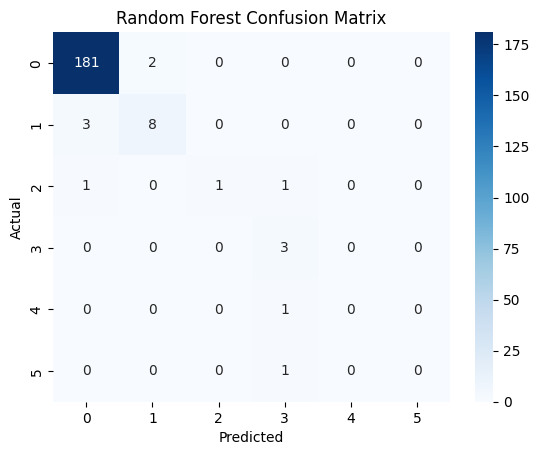

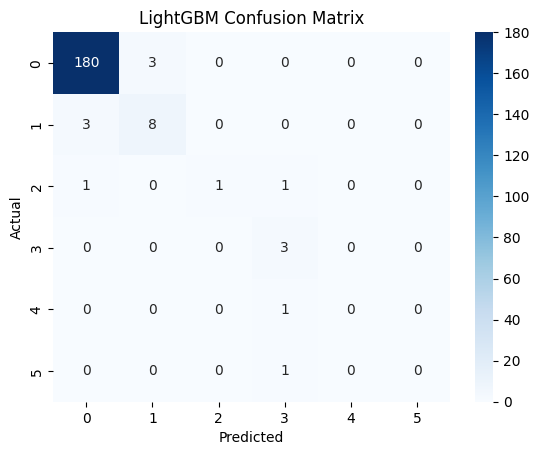

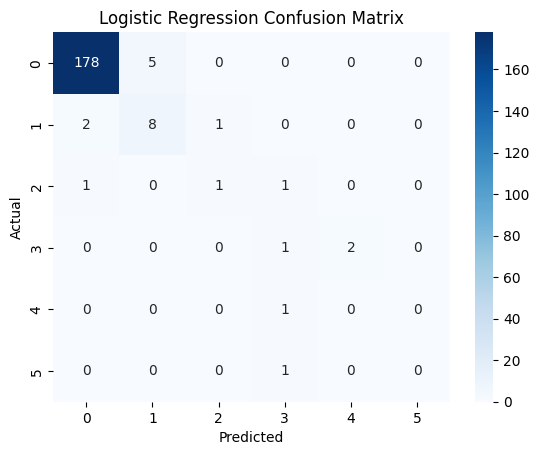

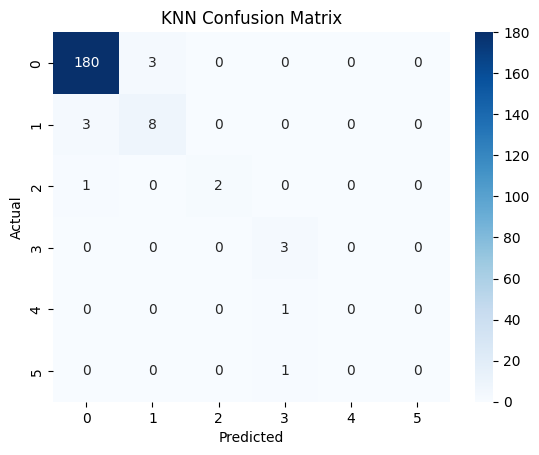

In [62]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=[cluster_reverse_mapping[i] for i in sorted(set(y))],
                yticklabels=[cluster_reverse_mapping[i] for i in sorted(set(y))])
    plt.title(title)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

for name, model in models.items():
    y_pred = model.predict(X_test)
    plot_confusion_matrix(y_test, y_pred, f"{name} Confusion Matrix")

"While the model performs well overall (93% accuracy), its performance on underrepresented classes such as 'Gold' and 'Diamond' is limited due to class imbalance. Future work could involve data augmentation, synthetic oversampling (e.g., SMOTE), or reclassification strategies to address this."

We combined Random Forest and LightGBM in a soft voting ensemble to leverage their complementary strengths: Random Forest’s overall stability and LightGBM’s sensitivity to minority classes. This strategy improved generalization, handled class imbalance more effectively, and resulted in a high-performing, balanced model suitable for deployment with awareness of its limitations on extremely rare classes.

In [65]:
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
lgb_model = lgb.LGBMClassifier(class_weight='balanced', random_state=42, verbose=-1)

# Create the ensemble with soft voting
ensemble = VotingClassifier(
    estimators=[('rf', rf_model), ('lgbm', lgb_model)],
    voting='soft'
)

# Fit on training data
ensemble.fit(X_train, y_train)

# Predict on test data
y_pred_ensemble = ensemble.predict(X_test)

# Evaluate performance
ensemble_accuracy = accuracy_score(y_test, y_pred_ensemble)
# Get the actual labels present in y_test
labels_present = sorted(unique_labels(y_test, y_pred_ensemble))

# Map to cluster names
target_names_present = [cluster_reverse_mapping[i] for i in labels_present]
'''
# Now create the report with explicit labels
ensemble_report = classification_report(
    y_test,
    y_pred_ensemble,
    labels=labels_present,
    target_names=target_names_present
)'''

print("Voting Ensemble Performance:")
print("Accuracy:", ensemble_accuracy)
'''
print("Classification Report:\n", ensemble_report)
'''

Voting Ensemble Performance:
Accuracy: 0.9504950495049505


'\nprint("Classification Report:\n", ensemble_report)\n'

In [71]:
wide_prediction_df.head()

,CustomerName,iteration_1,iteration_2,iteration_3,iteration_4,iteration_5,iteration_6,iteration_7,iteration_8,predicted_month_24,predicted_next_iteration
0,ADAMS PLC AND SONS,1,0,0,0,0,0,0,0,0,0
1,ADAMS PLC LTD,0,0,0,0,0,0,0,0,0,0
2,"AHMED, MURPHY AND STEVENSON LLC",0,0,0,0,0,0,0,0,0,0
3,AHMED-BAILEY GROUP,0,0,0,0,0,0,0,0,0,0
4,AKHTAR-AKHTAR LTD,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Predict the next month's clusters
wide_prediction_df['predicted_next_iteration'] = ensemble.predict(X)

# Save the updated dataframe to a CSV file
wide_prediction_df.to_csv(os.path.join(OUTPUT_DIR, 'processed', 'predicted_clusters_{TIME_SEPERATION}.csv'), index=False)